# ***2.2 Script for Descriptive Analysis:***




In [1]:
# Function to compute descriptive statistics
# sample --- the dataset or selected sample
# field  --- the column/variable for analysis

def Desc_stat(sample, field):

    col = sample[field]   # Store column once for clarity

    # Basic Central Tendency Measures
    mean = col.mean()
    median = col.median()
    mode = col.mode()
    mode_value = mode.iloc[0] if not mode.empty else None

    # Dispersion Measures
    minimum = col.min()
    maximum = col.max()
    data_range = maximum - minimum
    std_dev = col.std()
    variance = col.var()

    # Shape of Distribution
    skew = col.skew()
    kurtosis = col.kurt()

    # Quartiles
    q1 = col.quantile(0.25)
    q2 = col.quantile(0.50)
    q3 = col.quantile(0.75)
    iqr = q3 - q1

    # Count of Non-Missing Values
    count = col.count()

    # Store all results in a dictionary
    summary = {
        "Mean": mean,
        "Median": median,
        "Mode": mode_value,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": data_range,
        "Standard Deviation": std_dev,
        "Variance": variance,
        "Skewness": skew,
        "Kurtosis": kurtosis,
        "25th Percentile": q1,
        "50th Percentile": q2,
        "75th Percentile": q3,
        "Interquartile Range (IQR)": iqr,
        "Count": count
    }

    return summary

# ***2.3 Random Sampling:***

In [2]:
# Import required libraries
import pandas as pd

#  Load the dataset
data = pd.read_csv('final.csv')

# Define sample size
sample_size = 150

#  Generate a random sample of 150 observations (without replacement)
# random_state ensures reproducibility of results
sample = data.sample(n=sample_size, replace=False, random_state=42)

print('Random Sampling:')
# Apply the descriptive statistics function to the dependent variable
Desc_stat(sample, 'VehiclePrice')




Random Sampling:


{'Mean': np.float64(1153120.178928948),
 'Median': 1141532.8852397932,
 'Mode': np.float64(565466.6082924216),
 'Minimum': 565466.6082924216,
 'Maximum': 1796282.8788699517,
 'Range': 1230816.2705775301,
 'Standard Deviation': 306583.19154873124,
 'Variance': 93993253340.20604,
 'Skewness': np.float64(0.2132844391633631),
 'Kurtosis': np.float64(-0.6863182660648173),
 '25th Percentile': np.float64(930163.5078999116),
 '50th Percentile': np.float64(1141532.8852397932),
 '75th Percentile': np.float64(1361155.746528364),
 'Interquartile Range (IQR)': np.float64(430992.2386284524),
 'Count': np.int64(150)}

# ***2.4 Systematic Sampling:***

In [3]:
# SYSTEMATIC SAMPLING

import pandas as pd
import random  # Used to generate a random starting point

# Function to perform systematic sampling
# ds -- dataset
# sample_size -- desired number of observations

def systematic_sampling(ds, sample_size):

    # Calculate sampling interval (k)
    # This determines how frequently we select observations
    k = len(ds) // sample_size

    # Select a random starting index between 0 and k-1
    start_index = random.randint(0, k - 1)

    # Generate indices using systematic selection
    sample_indices = list(range(start_index, len(ds), k))

    # Extract rows based on selected indices
    sample = ds.iloc[sample_indices]

    # Ensure the sample size is exactly 150 observations
    sample = sample.head(sample_size)

    return sample


# Define sample size
sample_size = 150

# Generate systematic sample
sample = systematic_sampling(data, sample_size)


print('Systematic Sampling:')
# Apply descriptive statistics function to dependent variable
Desc_stat(sample, 'VehiclePrice')

Systematic Sampling:


{'Mean': np.float64(1131129.0871277957),
 'Median': 1110651.2651453565,
 'Mode': np.float64(615400.1696695797),
 'Minimum': 615400.1696695797,
 'Maximum': 1782393.980617981,
 'Range': 1166993.8109484012,
 'Standard Deviation': 288466.97678346175,
 'Variance': 83213196694.59026,
 'Skewness': np.float64(0.18594237462725113),
 'Kurtosis': np.float64(-0.5183115123716537),
 '25th Percentile': np.float64(951516.6563606877),
 '50th Percentile': np.float64(1110651.2651453565),
 '75th Percentile': np.float64(1320426.2971476465),
 'Interquartile Range (IQR)': np.float64(368909.64078695886),
 'Count': np.int64(150)}

# ***2.6 VISUALISATION THROUGH VARIOUS CHARTS***

# ***a) Scatter Plot:***

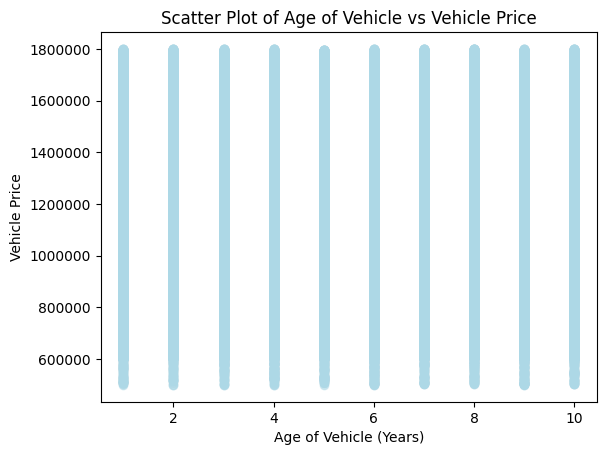

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('final.csv')

# Ensure variables are numeric
df['VehiclePrice'] = pd.to_numeric(df['VehiclePrice'], errors='coerce')
df['AgeOfVehicle'] = pd.to_numeric(df['AgeOfVehicle'], errors='coerce')

# Remove missing values
df = df.dropna(subset=['VehiclePrice', 'AgeOfVehicle'])

# Create scatter plot
plt.scatter(
    df['AgeOfVehicle'],
    df['VehiclePrice'],
    alpha=0.5,
    c='lightblue'
)

# Remove scientific notation on y-axis
plt.ticklabel_format(style='plain', axis='y')

# Labels and title
plt.xlabel('Age of Vehicle (Years)')
plt.ylabel('Vehicle Price')
plt.title('Scatter Plot of Age of Vehicle vs Vehicle Price')

plt.show()

# ***b) Box plot:***

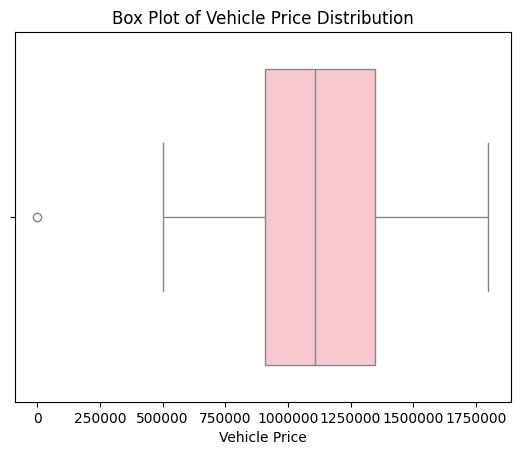

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('final.csv')

# Ensure VehiclePrice is numeric
df['VehiclePrice'] = pd.to_numeric(df['VehiclePrice'], errors='coerce')

# Remove missing values
df = df.dropna(subset=['VehiclePrice'])

# Create box plot
sns.boxplot(x=df['VehiclePrice'], color='pink')

# Improve x-axis formatting
plt.ticklabel_format(style='plain', axis='x')

# Labels and title
plt.xlabel('Vehicle Price')
plt.title('Box Plot of Vehicle Price Distribution')

plt.show()

# ***c) Histogram:***

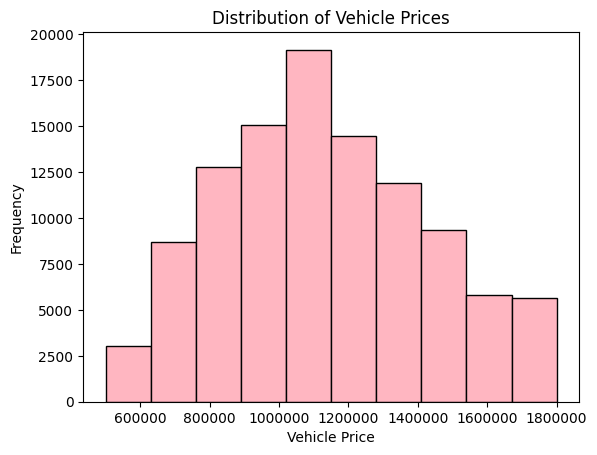

In [6]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('final.csv')

# Check if VehiclePrice is numeric (convert if needed)
df['VehiclePrice'] = pd.to_numeric(df['VehiclePrice'], errors='coerce')

# Remove missing values (if any)
df = df.dropna(subset=['VehiclePrice'])

# Create histogram for VehiclePrice
plt.hist(df['VehiclePrice'], bins=10, edgecolor='black', color='lightpink')

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='x')

# Add labels and title
plt.xlabel('Vehicle Price')
plt.ylabel('Frequency')
plt.title('Distribution of Vehicle Prices')

# Display the plot
plt.show()

# ***d) heatmap:***

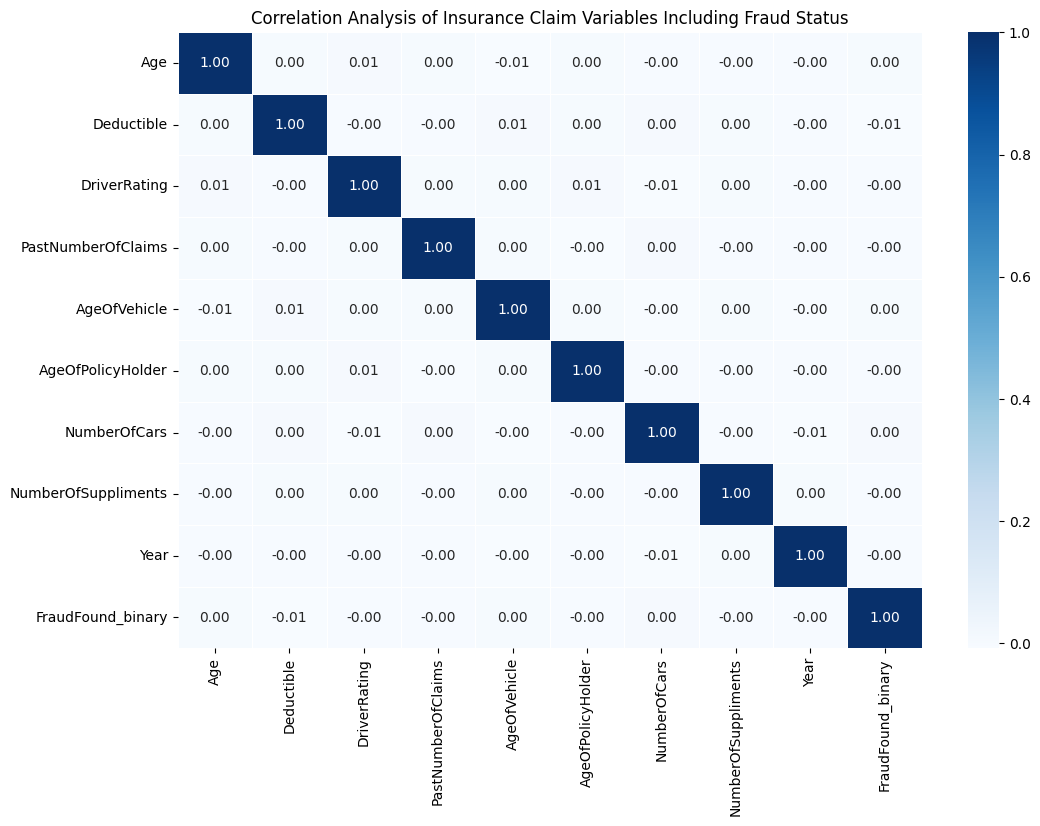

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('final.csv', on_bad_lines='skip')

# Convert FraudFound to numeric (0 = No, 1 = Yes)
data['FraudFound_binary'] = data['FraudFound'].map({'No': 0, 'Yes': 1})

# Select relevant numeric variables (excluding ClaimAmount because it is constant)
numeric_cols = [
    'Age',
    'Deductible',
    'DriverRating',
    'PastNumberOfClaims',
    'AgeOfVehicle',
    'AgeOfPolicyHolder',
    'NumberOfCars',
    'NumberOfSuppliments',
    'Year',
    'FraudFound_binary'
]

# Extract selected numeric data
numeric_data = data[numeric_cols]

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    linewidths=0.5
)

plt.title('Correlation Analysis of Insurance Claim Variables Including Fraud Status')
plt.show()

# ***2.6 Spearman Correlation Test:***

In [8]:
# Spearman Rank Correlation Test
import pandas as pd
from scipy.stats import spearmanr

# Load the dataset
df = pd.read_csv("final.csv")

# Select DriverRating and VehiclePrice columns
# Drop any missing values to ensure paired observations
data = df[['DriverRating', 'VehiclePrice']].dropna()

# Perform Spearman's Rank Correlation Test
r, p_value = spearmanr(data['DriverRating'], data['VehiclePrice'])

# Degrees of freedom (n - 2)
df_spearman = len(data) - 2

# Print the results
print("Spearman's Correlation Test Results:")
print(f"Spearman's Correlation Coefficient (r): {r:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {df_spearman}")

# Interpretation based on significance level (0.05)
if p_value < 0.05:
    print("\nConclusion: Since the p-value is less than 0.05, we reject the null hypothesis.")
    print("There is a statistically significant correlation between DriverRating and VehiclePrice.")
else:
    print("\nConclusion: Since the p-value is greater than 0.05, we fail to reject the null hypothesis.")
    print("There is no statistically significant correlation between DriverRating and VehiclePrice.")


Spearman's Correlation Test Results:
Spearman's Correlation Coefficient (r): 0.0026
P-Value: 0.3567
Degrees of Freedom: 121798

Conclusion: Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
There is no statistically significant correlation between DriverRating and VehiclePrice.


# ***2.6 Pearson Correlation Test:***

In [9]:
# Pearson Correlation Test
import pandas as pd
from scipy.stats import pearsonr

# Load the dataset
df = pd.read_csv("final.csv")

# Select DriverRating and VehiclePrice columns
# Drop missing values to ensure paired observations
data = df[['DriverRating', 'VehiclePrice']].dropna()

# Perform Pearson Correlation Test
r_value, p_value = pearsonr(data['DriverRating'], data['VehiclePrice'])

# Degrees of freedom (n - 2)
df_pearson = len(data) - 2

# Print the results
print("Pearson Correlation Test Results:")
print(f"Pearson Correlation Coefficient (r): {r_value:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {df_pearson}")

# Interpretation based on significance level (0.05)
if p_value < 0.05:
    print("\nConclusion: Since the p-value is less than 0.05, we reject the null hypothesis.")
    print("There is a statistically significant correlation between DriverRating and VehiclePrice.")
else:
    print("\nConclusion: Since the p-value is greater than 0.05, we fail to reject the null hypothesis.")
    print("There is no statistically significant correlation between DriverRating and VehiclePrice.")


Pearson Correlation Test Results:
Pearson Correlation Coefficient (r): 0.0023
P-Value: 0.4036
Degrees of Freedom: 127093

Conclusion: Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
There is no statistically significant correlation between DriverRating and VehiclePrice.


# ***2.6 Chi-Square Test:***

In [10]:
# Chi-Square Test of Independence

# a. Importing the libraries
import pandas as pd
from scipy.stats import chi2_contingency

# b. Importing the dataset
df = pd.read_csv("final.csv")

# c. Derive Cross Tabulation report for PoliceReportFiled and FraudFound
contingency_data = pd.crosstab(df['PoliceReportFiled'], df['FraudFound'], margins=False)

print("Contingency Table:")
print(contingency_data)

# d. Perform Chi-Square test for contingency table
chi2, p, dof, expected = chi2_contingency(contingency_data)

print("\nChi-Square Test Results:")
print('Chi-Square Statistic = %.4f, P-Value = %.4f' % (chi2, p))
print('Degrees of Freedom =', dof)

# Interpretation
if p > 0.05:
    print("\nConclusion: Independent categories")
else:
    print("\nConclusion: Dependent categories")


Contingency Table:
FraudFound            No    Yes
PoliceReportFiled              
No                 46050  19779
Yes                46563  19998

Chi-Square Test Results:
Chi-Square Statistic = 0.0000, P-Value = 1.0000
Degrees of Freedom = 1

Conclusion: Independent categories


# ***2.7 One Sample T-Test:***

In [11]:
# One Sample T-Test
# Importing the libraries
import pandas as pd
from scipy.stats import shapiro, ttest_1samp

# Importing the dataset
df = pd.read_csv("final.csv")

# Find the average(mean) of VehiclePrice for the entire dataset (population)
population_mean = df['VehiclePrice'].mean()
print("Population Mean:", population_mean)

# Extract a random sample of 150 VehiclePrice values
sample = df['VehiclePrice'].sample(n=150, random_state=1)

# Check whether sample data is normally distributed using Shapiro-Wilk test
r, p = shapiro(sample)
print('Shapiro Test: r=%.4f, p=%.4f' % (r, p))

if p > 0.05:
    print("Normal distribution")
else:
    print("Not a normal distribution")

# Conduct One-Sample T-Test
t_statistic, p_value = ttest_1samp(sample, population_mean)

print("\nOne-Sample T-Test Results:")
print("T-Statistic = %.4f" % t_statistic)
print("P-Value = %.4f" % p_value)

df_ttest = len(sample) - 1
print("Degrees of Freedom =", df_ttest)


Population Mean: 1132610.8828318603
Shapiro Test: r=0.9781, p=0.0169
Not a normal distribution

One-Sample T-Test Results:
T-Statistic = -0.4224
P-Value = 0.6733
Degrees of Freedom = 149
